In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
start = '2012-01-01'
end = '2022-12-21'
stock = 'GOOG'

data = yf.download(stock, start, end)

C:\Users\sahil\AppData\Local\Temp\ipykernel_17140\2194379965.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed


In [5]:
data.reset_index(inplace=True)

In [6]:
data

Price,Date,Close,High,Low,Open,Volume
Ticker,,GOOG,GOOG,GOOG,GOOG,GOOG
0,2012-01-03,16.438173,16.505863,16.116035,16.130117,147611217
1,2012-01-04,16.509071,16.557738,16.319840,16.428785,114989399
2,2012-01-05,16.280067,16.402599,16.211391,16.357144,131808205
3,2012-01-06,16.057983,16.304527,16.052300,16.283528,108119746
4,2012-01-09,15.377144,15.983377,15.346757,15.971023,233776981
...,...,...,...,...,...,...
2756,2022-12-14,94.533882,96.428333,93.175043,94.762013,26452900
2757,2022-12-15,90.457344,93.264301,89.693618,92.778293,28298800
2758,2022-12-16,90.120117,91.002869,89.277040,90.457345,48485500


In [7]:
ma_100_days = data.Close.rolling(100).mean()

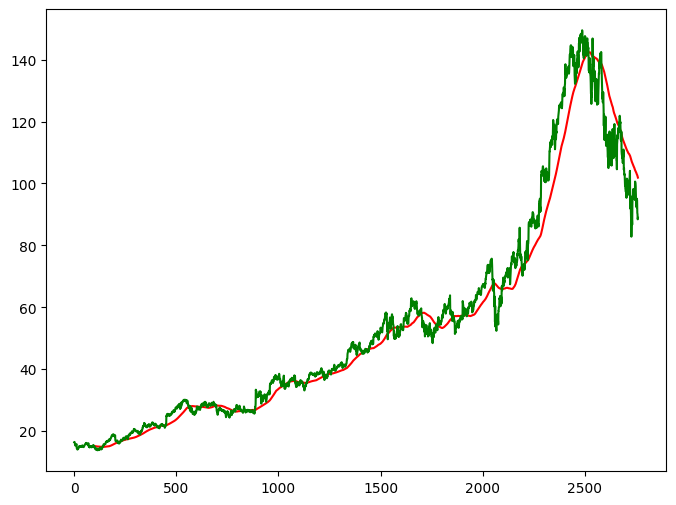

In [8]:
plt.figure(figsize=(8,6))
plt.plot(ma_100_days,'r')
plt.plot(data.Close,'g')
plt.show()

In [9]:
ma_200_days = data.Close.rolling(200).mean()

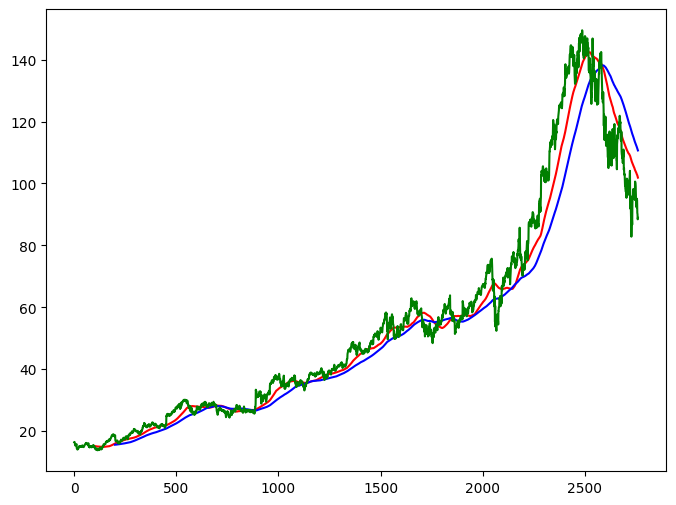

In [10]:
plt.figure(figsize=(8,6))
plt.plot(ma_100_days, 'r')
plt.plot(ma_200_days, 'b')
plt.plot(data.Close, 'g')
plt.show()

In [11]:
data.dropna(inplace=True)

In [17]:
data_train = pd.DataFrame(data.Close[0: int(len(data)*0.80)])
data_test = pd.DataFrame(data.Close[int(len(data)*0.80): len(data)])

In [21]:
data_train.shape[0]

2208

In [23]:
data_test.shape[0]

553

In [24]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [25]:
data_train_scale = scaler.fit_transform(data_train)

In [26]:
x = []
y = []
for i in range(100, data_train_scale.shape[0]):
    x.append(data_train_scale[i-100:i])
    y.append(data_train_scale[i,0])

In [29]:
x, y = np.array(x), np.array(y)

In [30]:
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

In [32]:
model = Sequential()
model.add(LSTM(units=50, activation='relu', return_sequences=True, input_shape=((x.shape[1],1))))

model.add(Dropout(0.2))

model.add(LSTM(units=60, activation='relu', return_sequences=True))
model.add(Dropout(0.3))

model.add(LSTM(units=80, activation='relu', return_sequences=True))
model.add(Dropout(0.4))

model.add(LSTM(units=120, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(units=1))

In [33]:
model.compile(optimizer="adam", loss="mean_squared_error")

In [34]:
model.fit(x,y, epochs=50, batch_size=32, verbose=1)

Epoch 1/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 22s 198ms/step - loss: 0.0396
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 20s 193ms/step - loss: 0.0080
Epoch 3/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 21s 194ms/step - loss: 0.0066
Epoch 4/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 14s 217ms/step - loss: 0.0052
Epoch 5/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 197ms/step - loss: 0.0051
Epoch 6/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 20s 184ms/step - loss: 0.0053
Epoch 7/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 185ms/step - loss: 0.0048
Epoch 8/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 187ms/step - loss: 0.0039
Epoch 9/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 194ms/step - loss: 0.0042
Epoch 10/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 196ms/step - loss: 0.0040
Epoch 11/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 181ms/step - loss: 0.0036
Epoch 12/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 188ms/step - loss: 0.0040
Epoch 13/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 15s 229ms/step - loss: 0.0035
Epoch 14/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 16s 248ms/step - loss: 0.0034
Epoch 15/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 21s 

In [35]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 100, 50)             │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 100, 50)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 100, 60)             │          26,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 100, 60)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 100, 80)             │          45,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 100, 80)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_4 (LSTM)                        │ (None, 120)                 │          96,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 120)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             121 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 536,285 (2.05 MB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 357,524 (1.36 MB)

In [36]:
pas_100_days = data_train.tail(100)

In [37]:
data_test = pd.concat([pas_100_days, data_test], ignore_index=True)

In [39]:
data_test_scale = scaler.fit_transform(data_test)

In [40]:
x = []
y = []
for i in range(100, data_test_scale.shape[0]):
    x.append(data_test_scale[i-100:i])
    y.append(data_test_scale[i,0])

x,y = np.array(x), np.array(y) 

In [41]:
y_predict = model.predict(x)

18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 249ms/step


In [42]:
y_predict

array([[0.12315521],
       [0.12268527],
       [0.12300658],
       [0.12416336],
       [0.1260908 ],
       [0.12867506],
       [0.13169068],
       [0.13489491],
       [0.13817039],
       [0.14151396],
       [0.14501843],
       [0.14864191],
       [0.15227965],
       [0.15570405],
       [0.15871659],
       [0.1613323 ],
       [0.16368037],
       [0.16597326],
       [0.16864458],
       [0.17208354],
       [0.17644131],
       [0.181689  ],
       [0.18778601],
       [0.19475956],
       [0.2022155 ],
       [0.20980483],
       [0.2172046 ],
       [0.22407436],
       [0.22999246],
       [0.23475853],
       [0.23821317],
       [0.24026243],
       [0.24118303],
       [0.24138871],
       [0.2413537 ],
       [0.24135743],
       [0.24178183],
       [0.24317752],
       [0.2458798 ],
       [0.24989647],
       [0.25492162],
       [0.26053324],
       [0.26622134],
       [0.27137223],
       [0.27545732],
       [0.2780475 ],
       [0.27878255],
       [0.277

In [48]:
scale = 1/scaler.scale_

In [49]:
y_predict = y_predict*scale

In [50]:
y = y*scale

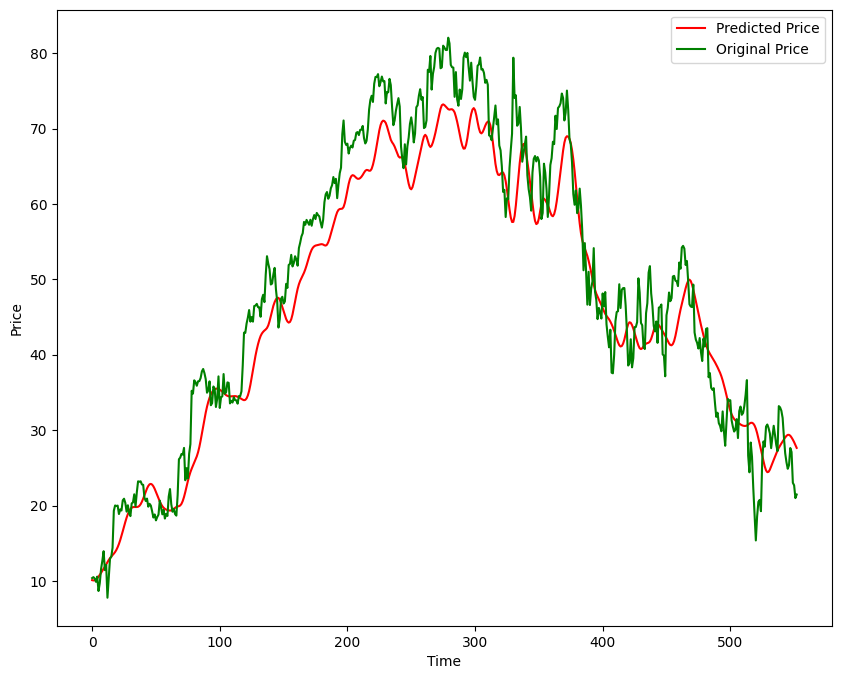

In [51]:
plt.figure(figsize=(10, 8))
plt.plot(y_predict, 'r', label='Predicted Price')
plt.plot(y, 'g', label='Original Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

In [52]:
model.save('Stock Predictions Model.keras')